---
**GUIA DE LABORATORIO 6 - Dos Formas de Medir el Azar**  
**Nombre:** Roberto Roly Copa Mamani  
**Mtaeria:** Machine Learning - INF 672

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from itertools import product
from collections import Counter

INDIGO = "#4F46E5"
PURPURA = "#7E22CE"
CORAL  = "#F43F5E"
TINTA  = "#111827"
CELDA  = "#F9FAFB"
HAIRLINE = "#E5E7EB"

mpl.rcParams.update({
    "font.family": ["DejaVu Sans", "sans-serif"],
    "font.size": 11,
    "axes.facecolor": CELDA,
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.color": HAIRLINE,
})

rng = np.random.default_rng(672)
print("Entorno listo. Paleta INF672 cargada.")

Entorno listo. Paleta INF672 cargada.


La semilla fija permite que las simulaciones sean reproducibles, algo importante cuando se comparan resultados experimentales

El enfoque clásico funciona cuando se conoce de antemano todos los resultados y estos son igualmente probables. El frecuentista es más útil cuando esa simetría no existe y necesita aprender a partir de observaciones

In [4]:
espacio_muestral = list(product(range(1, 7), repeat=2))
print(f"Total de resultados equiprobables: {len(espacio_muestral)}\n")

for d1 in range(1, 7):
  fila = "  ".join(f"({d1},{d2})" for d2 in range(1, 7))
  print(fila)

Total de resultados equiprobables: 36

(1,1)  (1,2)  (1,3)  (1,4)  (1,5)  (1,6)
(2,1)  (2,2)  (2,3)  (2,4)  (2,5)  (2,6)
(3,1)  (3,2)  (3,3)  (3,4)  (3,5)  (3,6)
(4,1)  (4,2)  (4,3)  (4,4)  (4,5)  (4,6)
(5,1)  (5,2)  (5,3)  (5,4)  (5,5)  (5,6)
(6,1)  (6,2)  (6,3)  (6,4)  (6,5)  (6,6)


Al principio podría parecer que existen solo 11 resultados porque las sumas van de 2 a 12, pero las sumas no son equiprobables. Los resultados realmente equiprobables son los 36 pares posibles de los dos dados

In [5]:
conteo = Counter(d1 + d2 for d1, d2 in espacio_muestral)

print(f"{'Suma':>5} {'Pares favorables':>17} {'Probabilidad':>14}")
print("-" * 40)
for suma in range(2, 13):
    favorables = conteo[suma]
    prob = favorables / 36
    print(f"{suma:>5} {favorables:>17} {prob:>10.4f}  ({favorables}/36)")

print(f"\nP(suma = 7) = {conteo[7]}/36 = {conteo[7]/36:.4f}")

 Suma  Pares favorables   Probabilidad
----------------------------------------
    2                 1     0.0278  (1/36)
    3                 2     0.0556  (2/36)
    4                 3     0.0833  (3/36)
    5                 4     0.1111  (4/36)
    6                 5     0.1389  (5/36)
    7                 6     0.1667  (6/36)
    8                 5     0.1389  (5/36)
    9                 4     0.1111  (4/36)
   10                 3     0.0833  (3/36)
   11                 2     0.0556  (2/36)
   12                 1     0.0278  (1/36)

P(suma = 7) = 6/36 = 0.1667


La suma 7 es la más probable porque puede obtenerse mediante seis combinaciones diferentes. Por eso su probabilidad es aproximadamente 16.67 %, y no 1/11

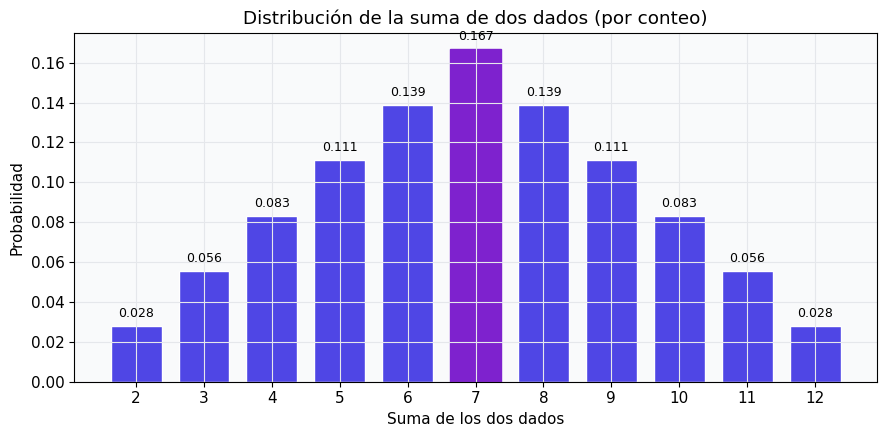

In [8]:
sumas = list(range(2, 13))
probs = [conteo[s] / 36 for s in sumas]

fig, ax = plt.subplots(figsize=(9, 4.5))
barras = ax.bar(sumas, probs, color=INDIGO, edgecolor="white", width=0.75)
barras[sumas.index(7)].set_color(PURPURA)

for s, p in zip(sumas, probs):
  ax.text(s, p + 0.003, f"{p:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_title("Distribución de la suma de dos dados (por conteo)")
ax.set_xlabel("Suma de los dos dados"); ax.set_ylabel("Probabilidad")
ax.set_xticks(sumas)
plt.tight_layout(); plt.show()

La forma triangular muestra que las sumas centrales tienen más maneras de ocurrir que las sumas extremas. Por eso 7 tiene la mayor probabilidad, mientras que 2 y 12 tienen las menores

/tmp/ipykernel_1567/1025017007.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(range(1, 7)); ax.set_yticklabels(range(1, 7))
/tmp/ipykernel_1567/1025017007.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(range(1, 7)); ax.set_yticklabels(range(1, 7))


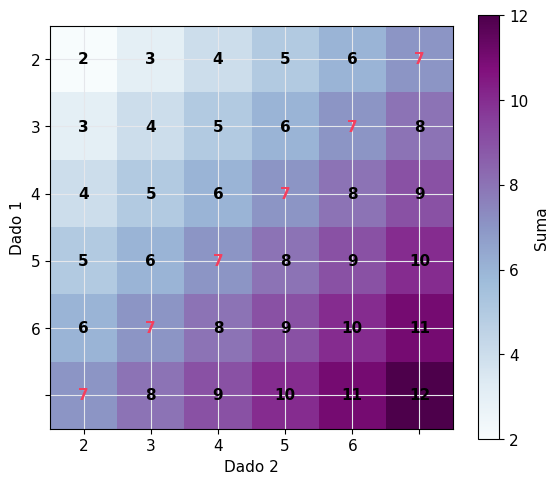

In [9]:
matriz = np.array([[d1 + d2 for d2 in range(1, 7)] for d1 in range(1, 7)])

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(matriz, cmap="BuPu", origin="upper")

for i in range(6):
  for j in range(6):
    es_siete = (matriz[i, j] == 7)
    ax.text(j, i, matriz[i, j], ha="center", va="center",
      color=CORAL if es_siete else "black", fontweight="bold")

ax.set_xticklabels(range(1, 7)); ax.set_yticklabels(range(1, 7))
ax.set_xlabel("Dado 2"); ax.set_ylabel("Dado 1")
plt.colorbar(im, ax=ax, label="Suma"); plt.show()

El mapa de calor permite ver por qué la suma 7 es la más probable: ocupa la diagonal más larga, formada por seis combinaciones. En cambio, las sumas 2 y 12 solo aparecen una vez

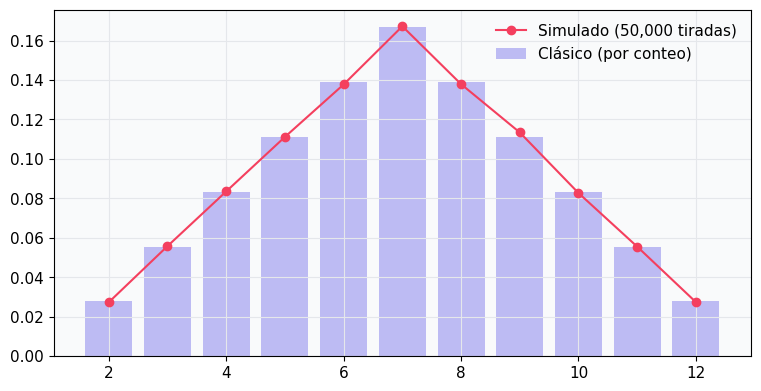

In [10]:
N = 50_000
d1 = rng.integers(1, 7, size=N)

d2 = rng.integers(1, 7, size=N)
sumas_simuladas = d1 + d2

conteo_sim = Counter(sumas_simuladas)
frec_obs = [conteo_sim[s] / N for s in sumas]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(sumas, probs, color=INDIGO, alpha=0.35, label="Clásico (por conteo)")
ax.plot(sumas, frec_obs, "o-", color=CORAL, label=f"Simulado ({N:,} tiradas)")
ax.legend(frameon=False); plt.show()

Con 50 000 simulaciones las frecuencias observadas se acercan mucho a las probabilidades teóricas. Esto muestra que el enfoque frecuentista puede recuperar experimentalmente el resultado que el enfoque clásico obtuvo mediante conteo

En Machine Learning normalmente no conocemos toda la distribución real de los datos. Por eso, aunque el enfoque clásico es exacto cuando existe simetría, el enfoque frecuentista se parece más a la situación real de aprendizaje: observamos datos y estimamos a partir de ellos

En una chincheta no puedo asumir que las dos posiciones tengan probabilidad 1/2, porque su forma no es simétrica. En este caso ya no basta con contar posibilidades, se necesita repetir el experimento y observar

In [11]:
def frecuencia_acumulada(resultados):
  resultados = np.asarray(resultados)
  aciertos_acumulados = np.cumsum(resultados)
  tiradas = np.arange(1, len(resultados) + 1)
  return aciertos_acumulados / tiradas

print(frecuencia_acumulada([1, 0, 1, 1]))

[1.         0.5        0.66666667 0.75      ]


La función calcula, después de cada repetición, qué proporción de resultados fueron favorables. En una secuencia de ceros y unos, esta frecuencia también puede verse como la media acumulada

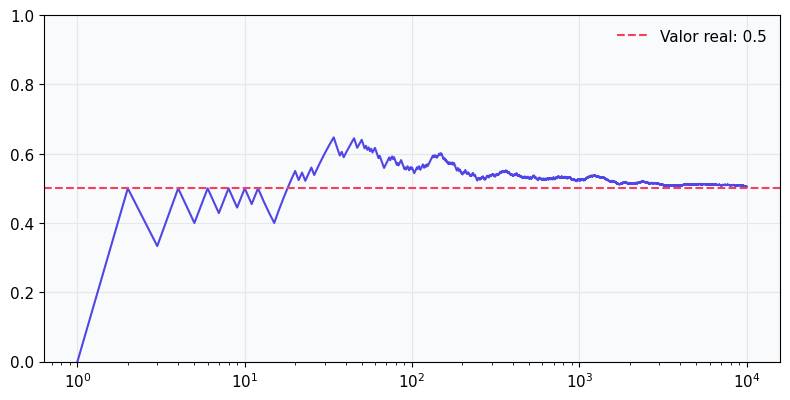

Estimación final: 0.5049 (el valor real es 0.5).


In [12]:
N = 10_000
lanzamientos = rng.integers(0, 2, size=N)

frec = frecuencia_acumulada(lanzamientos)
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(np.arange(1, N + 1), frec, color=INDIGO)
ax.axhline(0.5, color=CORAL, linestyle="--", label="Valor real: 0.5")
ax.set_xscale("log")

ax.set_ylim(0, 1); ax.legend(frameon=False); plt.show()
print(f"Estimación final: {frec[-1]:.4f} (el valor real es 0.5).")

Con pocas tiradas la estimación cambia mucho, pero al aumentar la cantidad de lanzamientos se estabiliza cerca de 0.5. Esto permite observar de manera práctica la ley de los grandes números

In [13]:
P_VERDADERA = 0.62

N = 10_000
chinchetas = (rng.random(N) < P_VERDADERA).astype(int)
frec = frecuencia_acumulada(chinchetas)
estimacion = frec[-1]

print(f"Tras {N:,} lanzamientos, estimamos P(punta arriba) ~ {estimacion:.4f}")

Tras 10,000 lanzamientos, estimamos P(punta arriba) ~ 0.6192


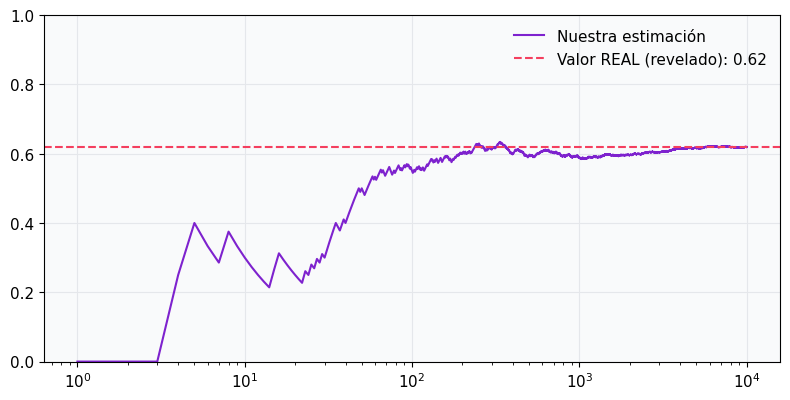

Estimación: 0.6192 | Real: 0.62 | Error: 0.0008


In [14]:
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(np.arange(1, N + 1), frec, color=PURPURA, label="Nuestra estimación")
ax.axhline(P_VERDADERA, color=CORAL, linestyle="--",
label=f"Valor REAL (revelado): {P_VERDADERA}")
ax.set_xscale("log"); ax.set_ylim(0, 1); ax.legend(frameon=False); plt.show()
print(f"Estimación: {estimacion:.4f} | Real: {P_VERDADERA} | Error: {abs(estimacion - P_VERDADERA):.4f}")

La probabilidad 0.62 no fue obtenida mediante una fórmula de conteo. La estimamos observando los resultados de muchas repeticiones. Esta situación se parece al Machine Learning, donde normalmente desconocemos la distribución verdadera y trabajamos únicamente con muestras

In [15]:
tamaños = [10, 100, 1_000, 10_000, 100_000]
estimaciones = []
for n in tamaños:
  muestra = (rng.random(n) < P_VERDADERA).astype(int)
  est = muestra.mean()
  estimaciones.append(est)
  print(f"{n:>8,}  estimación={est:.4f}  error={abs(est - P_VERDADERA):.4f}")

      10  estimación=0.4000  error=0.2200
     100  estimación=0.5600  error=0.0600
   1,000  estimación=0.6090  error=0.0110
  10,000  estimación=0.6156  error=0.0044
 100,000  estimación=0.6206  error=0.0006


Con muestras pequeñas la estimación puede alejarse bastante del valor real. A medida que aumenta el número de observaciones, la estimación tiende a ser más estable y precisa

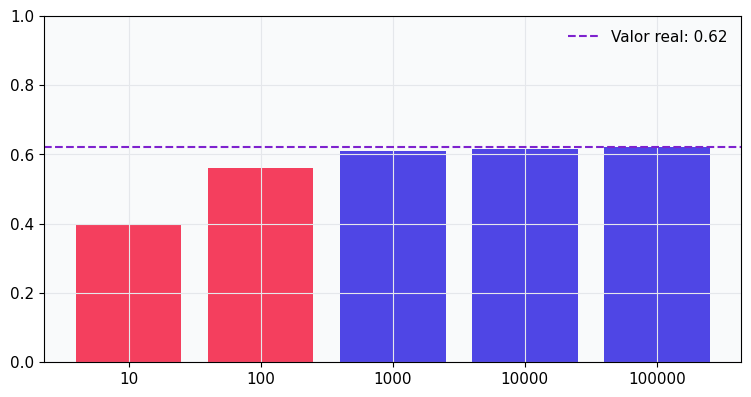

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colores = [CORAL if abs(e - P_VERDADERA) > 0.03 else INDIGO for e in estimaciones]
ax.bar([str(n) for n in tamaños], estimaciones, color=colores)
ax.axhline(P_VERDADERA, color=PURPURA, linestyle="--", label=f"Valor real: {P_VERDADERA}")
ax.set_ylim(0, 1); ax.legend(frameon=False); plt.show()

Este resultado muestra por qué la cantidad de datos es importante. Con pocos datos una estimación puede ser muy variable, con más observaciones disminuye la incertidumbre

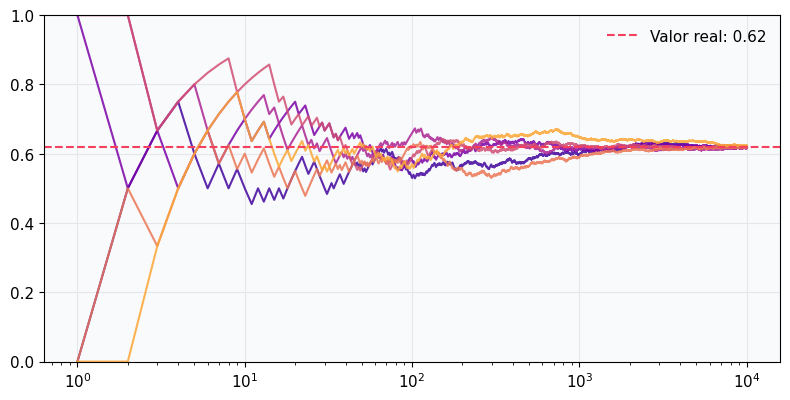

In [21]:
N = 10_000
n_corridas = 6

fig, ax = plt.subplots(figsize=(9.5, 4.5))
paleta = plt.cm.plasma(np.linspace(0.1, 0.8, n_corridas))

for k in range(n_corridas):
  rng_k = np.random.default_rng(k)
  muestra = (rng_k.random(N) < P_VERDADERA).astype(int)
  ax.plot(np.arange(1, N + 1), frecuencia_acumulada(muestra), color=paleta[k], alpha=0.85)
ax.axhline(P_VERDADERA, color=CORAL, linestyle="--", label=f"Valor real: {P_VERDADERA}")
ax.set_xscale("log"); ax.set_ylim(0, 1); ax.legend(frameon=False); plt.show()

Aunque todas las corridas buscan estimar la misma probabilidad, cada muestra produce un camino diferente. Esto demuestra que una estimación obtenida a partir de una muestra finita también tiene variabilidad

Esta práctica ayuda a entender que un modelo de Machine Learning también aprende a partir de muestras. No conoce directamente la distribución verdadera de la realidad, sino que estima patrones desde los datos disponibles. Por eso una cantidad insuficiente de datos puede producir estimaciones inestables y favorecer problemas como el sobreajuste